# HW10-11: Computer Vision with PyTorch
## Part A: Image Classification (STL-10)
## Part B: Semantic Segmentation (OxfordIIITPet)

## 1. Импорты, seed и устройство

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from pathlib import Path
import warnings
from PIL import Image
from scipy import ndimage
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'Torchvision: {torchvision.__version__}')

PyTorch: 2.10.0
Torchvision: 0.25.0


In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cpu


## 2. Загрузка данных для части A (STL-10)

In [3]:
data_dir = Path('./data')
data_dir.mkdir(exist_ok=True)

train_dataset = datasets.STL10(root=str(data_dir), split='train', download=True, transform=None)
test_dataset = datasets.STL10(root=str(data_dir), split='test', download=True, transform=None)

print(f'Train size: {len(train_dataset)}, Test size: {len(test_dataset)}, Classes: {len(train_dataset.classes)}')
print(f'Classes: {train_dataset.classes}')

Train size: 5000, Test size: 8000, Classes: 10
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [4]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_split, val_split = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

print(f'Train: {len(train_split)}, Val: {len(val_split)}, Test: {len(test_dataset)}')

Train: 4000, Val: 1000, Test: 8000


## 3. Трансформации и аугментации

In [5]:
IMG_SIZE = 96

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

augmented_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_transform = basic_transform
print('Transforms created')

Transforms created


## 4. DataLoaders

In [6]:
class DatasetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

train_data_basic = DatasetWithTransform(train_split, basic_transform)
val_data = DatasetWithTransform(val_split, basic_transform)
test_data = DatasetWithTransform(test_dataset, basic_transform)
train_data_aug = DatasetWithTransform(train_split, augmented_transform)

BATCH_SIZE = 32
train_loader_basic = DataLoader(train_data_basic, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
train_loader_aug = DataLoader(train_data_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'DataLoaders created')

DataLoaders created


## 5. Sanity-check

Batch shape: torch.Size([32, 3, 96, 96]), Labels: torch.Size([32])


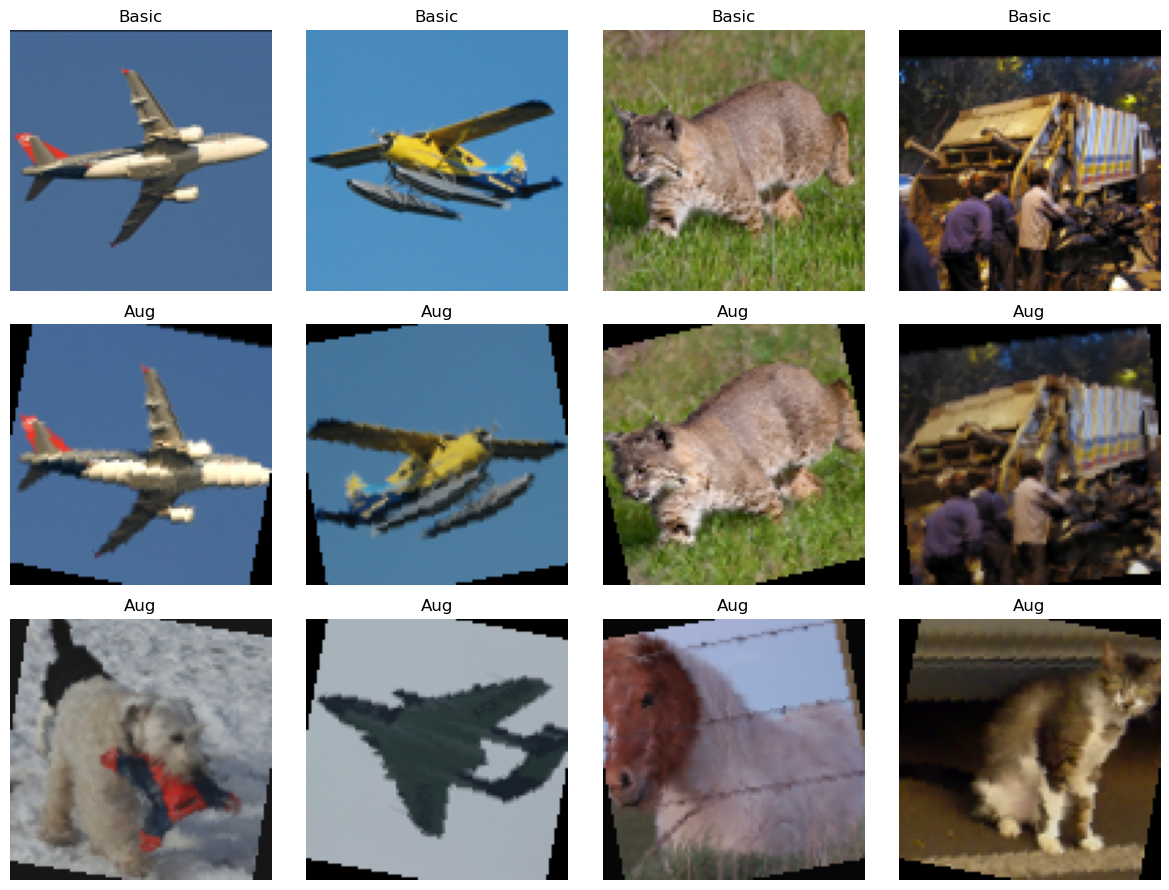

In [7]:
x, y = next(iter(train_loader_basic))
print(f'Batch shape: {x.shape}, Labels: {y.shape}')

def denormalize(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    return torch.clamp(t * std + mean, 0, 1)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i in range(4):
    img, label = train_data_basic[i]
    axes[0, i].imshow(denormalize(img).permute(1, 2, 0).numpy())
    axes[0, i].set_title('Basic')
    axes[0, i].axis('off')
for i in range(4):
    img, label = train_data_aug[i]
    axes[1, i].imshow(denormalize(img).permute(1, 2, 0).numpy())
    axes[1, i].set_title('Aug')
    axes[1, i].axis('off')
for i in range(4, 8):
    img, label = train_data_aug[i]
    axes[2, i-4].imshow(denormalize(img).permute(1, 2, 0).numpy())
    axes[2, i-4].set_title('Aug')
    axes[2, i-4].axis('off')
plt.tight_layout()
plt.savefig('./artifacts/figures/augmentations_preview.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Training functions

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = logits.max(1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)
    return total_loss / len(loader), total_correct / total_samples

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item()
            _, preds = logits.max(1)
            total_correct += (preds == y).sum().item()
            total_samples += y.size(0)
    return total_loss / len(loader), total_correct / total_samples

## 7-10. CNN Experiments C1-C4

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 12 * 12, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

criterion = nn.CrossEntropyLoss()
NUM_EPOCHS = 20
results_a = {}

In [10]:
for exp, (loader, lr_val) in [('C1', (train_loader_basic, 0.01)), ('C2', (train_loader_aug, 0.01))]:
    print(f'Training {exp}')
    torch.manual_seed(SEED)
    model = SimpleCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr_val, momentum=0.9)
    best_acc, best_state = 0, None
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_state = val_acc, model.state_dict().copy()
        if (epoch+1) % 5 == 0:
            print(f'  Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')
    
    results_a[exp] = {'best_val_acc': best_acc, 'model': best_state, 'model_obj': model, 'history': hist}
    print(f'{exp} best: {best_acc:.4f}')

Training C1
  Epoch 5: train_acc=0.5750, val_acc=0.5460
  Epoch 10: train_acc=0.8265, val_acc=0.5850
  Epoch 15: train_acc=0.9397, val_acc=0.5820
  Epoch 20: train_acc=0.9660, val_acc=0.5550
C1 best: 0.5880
Training C2
  Epoch 5: train_acc=0.4235, val_acc=0.4920
  Epoch 10: train_acc=0.5292, val_acc=0.5310
  Epoch 15: train_acc=0.6052, val_acc=0.5790
  Epoch 20: train_acc=0.6585, val_acc=0.5940
C2 best: 0.6180


In [11]:
for exp in ['C3', 'C4']:
    print(f'Training {exp}')
    torch.manual_seed(SEED)
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)
    
    if exp == 'C3':
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, 10).to(device)
        optimizer = optim.SGD(model.fc.parameters(), lr=0.01, momentum=0.9)
    else:  # C4
        for param in model.layer1.parameters():
            param.requires_grad = False
        for param in model.layer2.parameters():
            param.requires_grad = False
        for param in model.layer3.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, 10).to(device)
        finetune_params = list(model.layer4.parameters()) + list(model.fc.parameters())
        optimizer = optim.SGD(finetune_params, lr=0.001, momentum=0.9)
    
    best_acc, best_state = 0, None
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader_basic, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_state = val_acc, model.state_dict().copy()
        if (epoch+1) % 5 == 0:
            print(f'  Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')
    
    results_a[exp] = {'best_val_acc': best_acc, 'model': best_state, 'model_obj': model, 'history': hist}
    print(f'{exp} best: {best_acc:.4f}')

Training C3
  Epoch 5: train_acc=0.8007, val_acc=0.7730
  Epoch 10: train_acc=0.8297, val_acc=0.7630
  Epoch 15: train_acc=0.8438, val_acc=0.7610
  Epoch 20: train_acc=0.8448, val_acc=0.7330
C3 best: 0.7740
Training C4
  Epoch 5: train_acc=0.9705, val_acc=0.8570
  Epoch 10: train_acc=0.9958, val_acc=0.8590
  Epoch 15: train_acc=0.9965, val_acc=0.8630
  Epoch 20: train_acc=0.9985, val_acc=0.8680
C4 best: 0.8680


## 11. Comparison and best model

Results: [('C1', '0.5880'), ('C2', '0.6180'), ('C3', '0.7740'), ('C4', '0.8680')]
Best: C4 with 0.8680


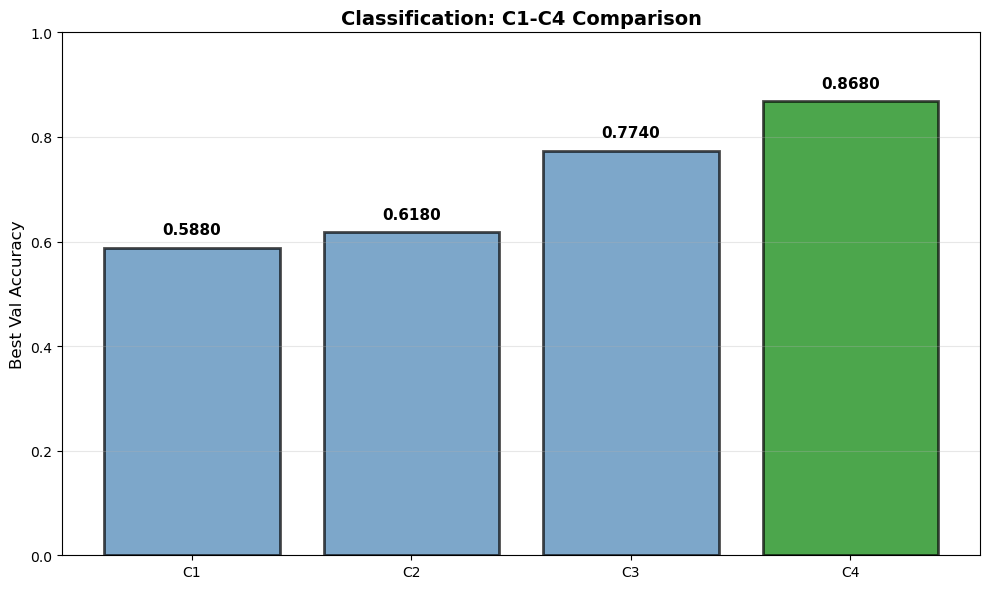

In [13]:
best_exp = max(results_a, key=lambda x: results_a[x]['best_val_acc'])
best_val_acc = results_a[best_exp]['best_val_acc']
print(f'Results: {[(k, f"{v["best_val_acc"]:.4f}") for k, v in results_a.items()]}')
print(f'Best: {best_exp} with {best_val_acc:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
exps = list(results_a.keys())
accs = [results_a[e]['best_val_acc'] for e in exps]
colors = ['green' if e == best_exp else 'steelblue' for e in exps]
ax.bar(exps, accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Best Val Accuracy', fontsize=12)
ax.set_title('Classification: C1-C4 Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
for bar, acc in zip(ax.patches, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./artifacts/figures/classification_compare.png', dpi=100, bbox_inches='tight')
plt.show()

## 12. Test evaluation

Test Acc: 0.8631


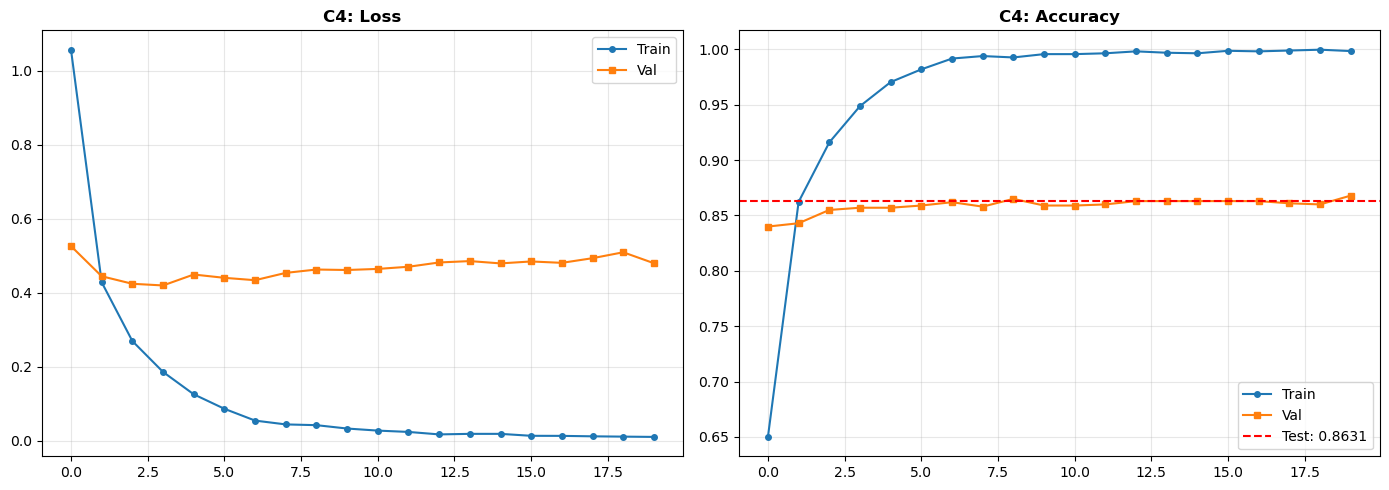

In [14]:
best_model_obj = results_a[best_exp]['model_obj']
best_model_obj.load_state_dict(results_a[best_exp]['model'])
test_loss, test_acc = evaluate(best_model_obj, test_loader, criterion, device)
print(f'Test Acc: {test_acc:.4f}')

best_history = results_a[best_exp]['history']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(best_history['train_loss'], label='Train', marker='o', markersize=4)
axes[0].plot(best_history['val_loss'], label='Val', marker='s', markersize=4)
axes[0].set_title(f'{best_exp}: Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(best_history['train_acc'], label='Train', marker='o', markersize=4)
axes[1].plot(best_history['val_acc'], label='Val', marker='s', markersize=4)
axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test: {test_acc:.4f}')
axes[1].set_title(f'{best_exp}: Accuracy', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./artifacts/figures/classification_curves_best.png', dpi=100, bbox_inches='tight')
plt.show()

## 13-16. Segmentation Part B

In [ ]:
pet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=Image.NEAREST),
    transforms.PILToTensor(),
    transforms.Lambda(lambda t: (t[0] > 0).float())
])

pet_dataset = datasets.OxfordIIITPet(
    root=str(data_dir),
    split='trainval',
    target_types='segmentation',
    download=True,
    transform=pet_transform,
    target_transform=mask_transform
)
print(f'OxfordIIITPet: {len(pet_dataset)} samples')

seg_loader = DataLoader(pet_dataset, batch_size=4, shuffle=False, num_workers=0)
seg_dataset = pet_dataset
print(f'Seg dataset created: {len(seg_dataset)} samples')

OxfordIIITPet: 3680 samples
Seg dataset created: 3680 samples


In [21]:
if seg_dataset:
    seg_model = models.segmentation.deeplabv3_resnet50(weights=models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1).to(device)
    seg_model.eval()
    print('DeepLabV3 loaded')
    
    def postprocess_v1(output):
        return torch.argmax(output['out'], dim=1)
    
    def postprocess_v2(output):
        output = torch.argmax(output['out'], dim=1)
        output_np = output.cpu().numpy()
        result = []
        for mask in output_np:
            binary_mask = (mask > 0).astype(np.uint8)
            binary_mask = ndimage.binary_closing(binary_mask, structure=np.ones((3, 3))).astype(np.uint8)
            binary_mask = ndimage.binary_opening(binary_mask, structure=np.ones((3, 3))).astype(np.uint8)
            labeled, num_features = ndimage.label(binary_mask)
            if num_features > 0:
                sizes = ndimage.sum(binary_mask, labeled, range(num_features + 1))
                for s in range(1, num_features + 1):
                    if sizes[s] < 50:
                        binary_mask[labeled == s] = 0
            result.append(binary_mask)
        return torch.tensor(np.array(result), device=output.device)
    
    v1_pred, v2_pred = [], []
    with torch.no_grad():
        for idx in range(min(10, len(seg_dataset))):
            img, gt_mask = seg_dataset[idx]
            output = seg_model(img.unsqueeze(0).to(device))
            v1_pred.append((img, gt_mask, postprocess_v1(output).squeeze().cpu()))
            v2_pred.append((img, gt_mask, postprocess_v2(output).squeeze().cpu()))
    print(f'Predictions: V1={len(v1_pred)}, V2={len(v2_pred)}')

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /Users/artempetrov/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:23<00:00, 7.19MB/s] 


DeepLabV3 loaded
Predictions: V1=10, V2=10


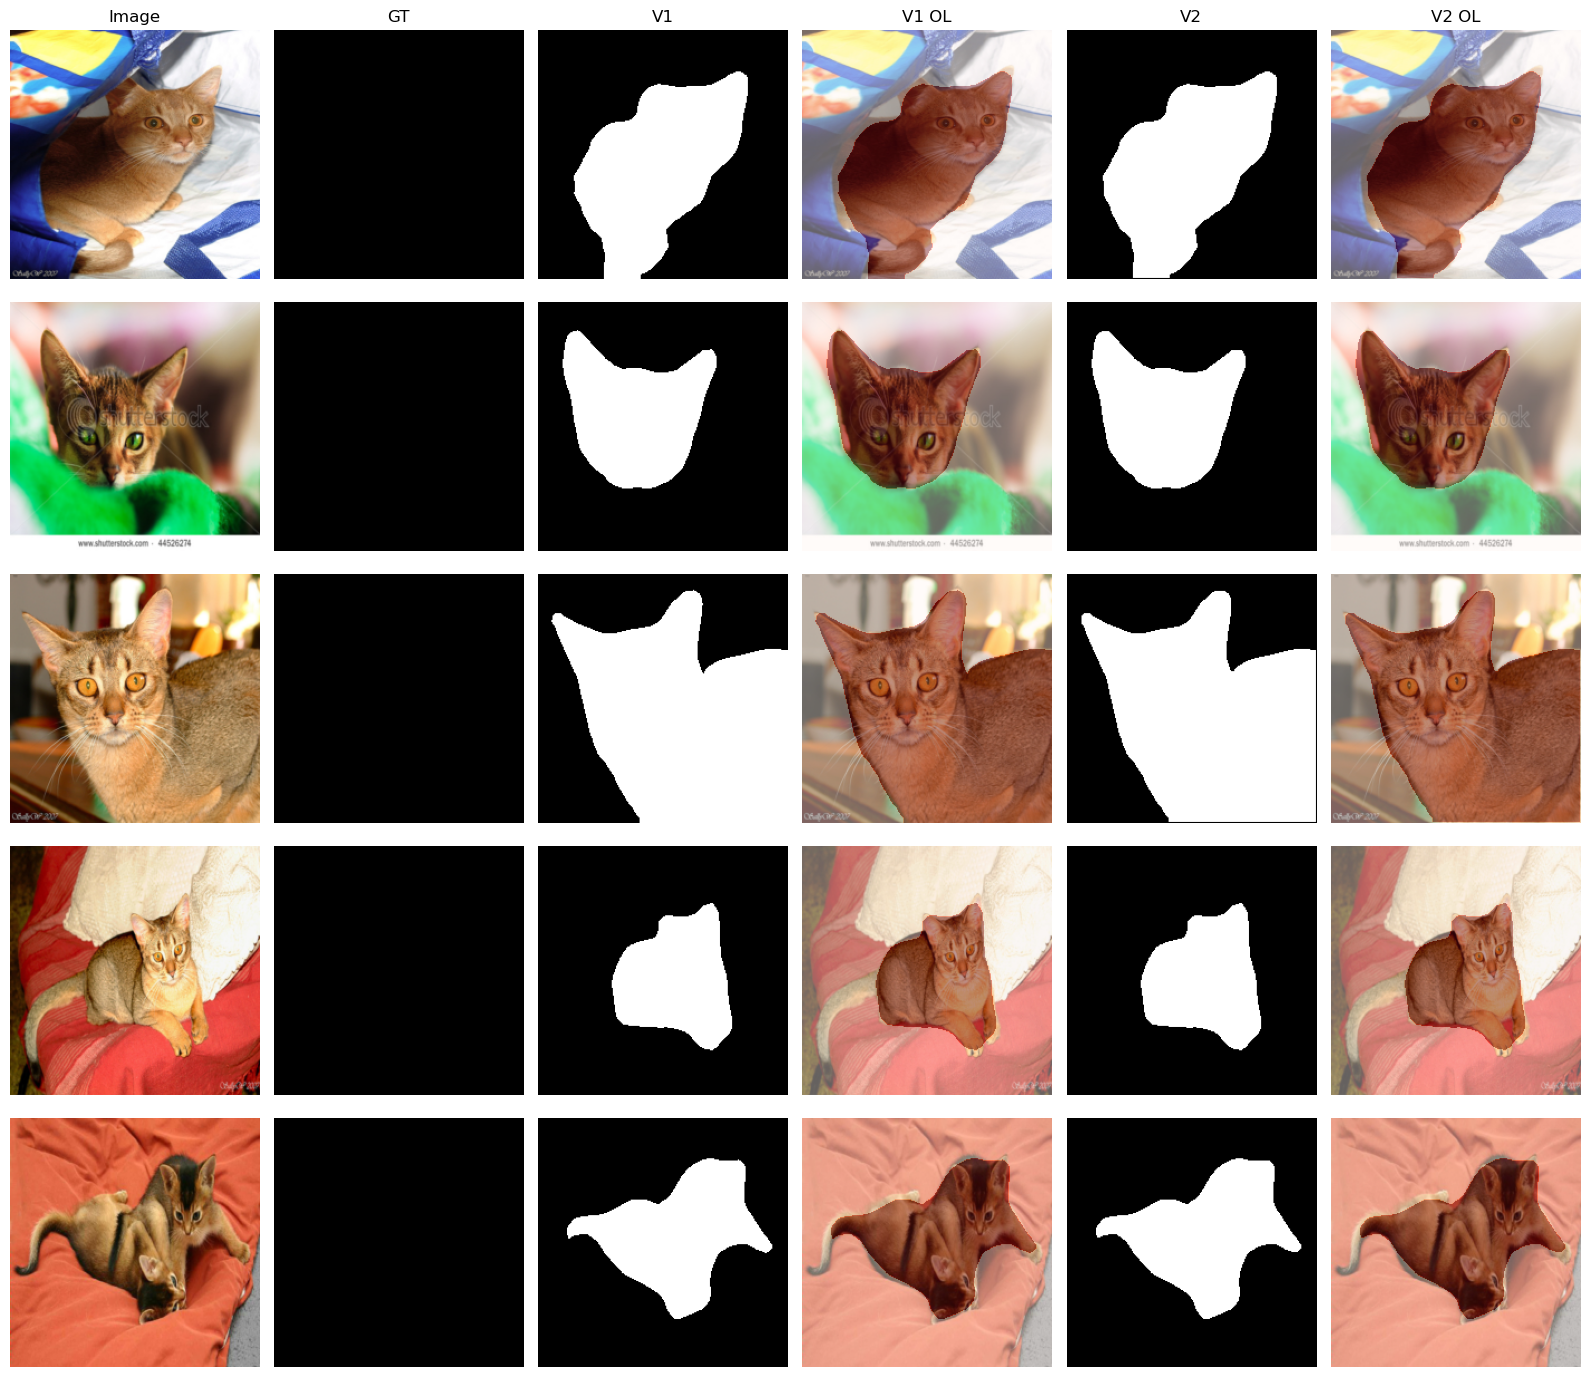

In [22]:
if v1_pred and v2_pred:
    fig, axes = plt.subplots(5, 6, figsize=(16, 14))
    mean_denorm = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std_denorm = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    
    for row in range(5):
        img, gt, v1 = v1_pred[row]
        _, _, v2 = v2_pred[row]
        img_denorm = torch.clamp(img * std_denorm + mean_denorm, 0, 1)
        
        axes[row, 0].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[row, 0].set_title('Image' if row == 0 else '')
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(gt.numpy(), cmap='gray')
        axes[row, 1].set_title('GT' if row == 0 else '')
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow((v1 > 0).numpy(), cmap='gray')
        axes[row, 2].set_title('V1' if row == 0 else '')
        axes[row, 2].axis('off')
        
        axes[row, 3].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[row, 3].imshow((v1 > 0).numpy(), cmap='Reds', alpha=0.4)
        axes[row, 3].set_title('V1 OL' if row == 0 else '')
        axes[row, 3].axis('off')
        
        axes[row, 4].imshow((v2 > 0).numpy(), cmap='gray')
        axes[row, 4].set_title('V2' if row == 0 else '')
        axes[row, 4].axis('off')
        
        axes[row, 5].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[row, 5].imshow((v2 > 0).numpy(), cmap='Reds', alpha=0.4)
        axes[row, 5].set_title('V2 OL' if row == 0 else '')
        axes[row, 5].axis('off')
    
    plt.tight_layout()
    plt.savefig('./artifacts/figures/segmentation_examples.png', dpi=100, bbox_inches='tight')
    plt.show()

## 17-18. Metrics and export

In [23]:
def calc_iou(pred, gt):
    pred, gt = pred.float(), gt.float()
    inter = (pred * gt).sum()
    union = pred.sum() + gt.sum() - inter
    return (inter / union).item() if union > 0 else 0.0

def calc_prec(pred, gt):
    pred, gt = pred.float(), gt.float()
    tp = (pred * gt).sum()
    pp = pred.sum()
    return (tp / pp).item() if pp > 0 else 0.0

def calc_rec(pred, gt):
    pred, gt = pred.float(), gt.float()
    tp = (pred * gt).sum()
    ap = gt.sum()
    return (tp / ap).item() if ap > 0 else 0.0

if v1_pred and v2_pred:
    v1_metrics = {'iou': [], 'prec': [], 'rec': []}
    v2_metrics = {'iou': [], 'prec': [], 'rec': []}
    
    for i in range(len(v1_pred)):
        _, gt, v1 = v1_pred[i]
        _, _, v2 = v2_pred[i]
        v1_bin = (v1 > 0).float()
        v2_bin = (v2 > 0).float()
        v1_metrics['iou'].append(calc_iou(v1_bin, gt))
        v1_metrics['prec'].append(calc_prec(v1_bin, gt))
        v1_metrics['rec'].append(calc_rec(v1_bin, gt))
        v2_metrics['iou'].append(calc_iou(v2_bin, gt))
        v2_metrics['prec'].append(calc_prec(v2_bin, gt))
        v2_metrics['rec'].append(calc_rec(v2_bin, gt))
    
    mean_v1 = {k: np.mean(v) for k, v in v1_metrics.items()}
    mean_v2 = {k: np.mean(v) for k, v in v2_metrics.items()}
    
    print(f'V1: IoU={mean_v1["iou"]:.4f}, Prec={mean_v1["prec"]:.4f}, Rec={mean_v1["rec"]:.4f}')
    print(f'V2: IoU={mean_v2["iou"]:.4f}, Prec={mean_v2["prec"]:.4f}, Rec={mean_v2["rec"]:.4f}')

V1: IoU=0.4355, Prec=1.0000, Rec=0.4355
V2: IoU=0.4318, Prec=1.0000, Rec=0.4318


Artifacts saved


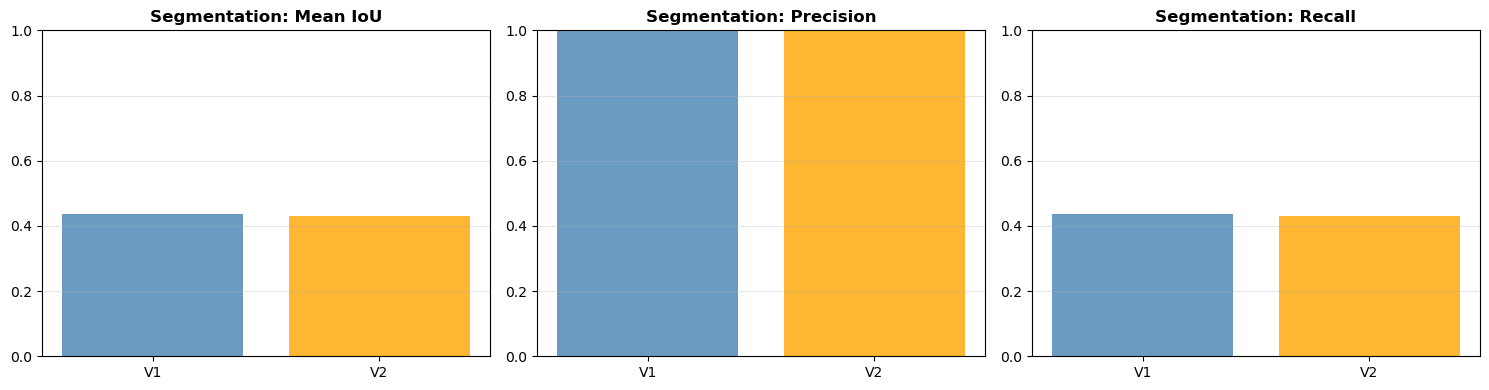

In [24]:
# Save artifacts
torch.save(results_a[best_exp]['model'], './artifacts/best_classifier.pt')

config = {
    'dataset': 'STL-10',
    'best_exp': best_exp,
    'image_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'seed': SEED,
    'best_val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc)
}
with open('./artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

# Create runs.csv
runs_data = []
for exp_id in ['C1', 'C2', 'C3', 'C4']:
    runs_data.append({
        'experiment_id': exp_id,
        'task': 'classification',
        'dataset': 'STL-10',
        'seed': SEED,
        'model_summary': exp_id,
        'optimizer': 'SGD',
        'lr': '0.01' if exp_id in ['C1', 'C2', 'C3'] else '0.001',
        'epochs_trained': NUM_EPOCHS,
        'best_val_accuracy': f'{results_a[exp_id]["best_val_acc"]:.6f}',
        'test_accuracy': f'{test_acc:.6f}' if exp_id == best_exp else '',
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': 'Best' if exp_id == best_exp else ''
    })

if seg_dataset:
    runs_data.extend([
        {'experiment_id': 'V1', 'task': 'segmentation', 'dataset': 'OxfordIIITPet', 'seed': SEED, 'model_summary': 'DeepLabV3', 'optimizer': 'N/A', 'lr': 'N/A', 'epochs_trained': 0, 'best_val_accuracy': '', 'test_accuracy': '', 'precision': f'{mean_v1["prec"]:.6f}', 'recall': f'{mean_v1["rec"]:.6f}', 'mean_iou': f'{mean_v1["iou"]:.6f}', 'notes': 'Basic'},
        {'experiment_id': 'V2', 'task': 'segmentation', 'dataset': 'OxfordIIITPet', 'seed': SEED, 'model_summary': 'DeepLabV3', 'optimizer': 'N/A', 'lr': 'N/A', 'epochs_trained': 0, 'best_val_accuracy': '', 'test_accuracy': '', 'precision': f'{mean_v2["prec"]:.6f}', 'recall': f'{mean_v2["rec"]:.6f}', 'mean_iou': f'{mean_v2["iou"]:.6f}', 'notes': 'Morpho'}
    ])

pd.DataFrame(runs_data).to_csv('./artifacts/runs.csv', index=False)
print('Artifacts saved')

if seg_dataset:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for idx, (ax, metric) in enumerate(zip(axes, ['Mean IoU', 'Precision', 'Recall'])):
        keys = ['iou', 'prec', 'rec']
        v1_val = mean_v1[keys[idx]]
        v2_val = mean_v2[keys[idx]]
        ax.bar(['V1', 'V2'], [v1_val, v2_val], color=['steelblue', 'orange'], alpha=0.8)
        ax.set_title(f'Segmentation: {metric}', fontweight='bold')
        ax.set_ylim([0, 1])
        ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('./artifacts/figures/segmentation_metrics.png', dpi=100, bbox_inches='tight')
    plt.show()

## Summary

In [25]:
print('='*60)
print('HW10-11 SUMMARY')
print('='*60)
print('\nPart A: Classification')
for exp, data in results_a.items():
    print(f'  {exp}: {data["best_val_acc"]:.4f}')
print(f'  Test ({best_exp}): {test_acc:.4f}')
if seg_dataset:
    print('\nPart B: Segmentation')
    print(f'  V1 IoU: {mean_v1["iou"]:.4f}')
    print(f'  V2 IoU: {mean_v2["iou"]:.4f}')
print('\nArtifacts saved to ./artifacts/')
print('='*60)

HW10-11 SUMMARY

Part A: Classification
  C1: 0.5880
  C2: 0.6180
  C3: 0.7740
  C4: 0.8680
  Test (C4): 0.8631

Part B: Segmentation
  V1 IoU: 0.4355
  V2 IoU: 0.4318

Artifacts saved to ./artifacts/
